<img style="float: right;" src="https://www.h-ka.de/typo3conf/ext/in2template/Resources/Public/Images/Icons/Favicons/favicon-256x256.png">

# Transfer Learning

In this tutorial, you will learn how to train a convolutional neural network for image classification using transfer learning.

The problem we’re going to solve is to train a model to classify ants and bees. We have about 120 training images each for ants and bees (this dataset is a very small subset of imagenet). There are 75 validation images for each class. Usually, this is a very small dataset to generalize upon, if trained from scratch. Since we are using transfer learning, we should be able to generalize reasonably well.

The original code for this exercise was written by Sasank Chilamkurthy and published as a [pytorch tutorial](https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html). The code was modified to fit the syllabus for the lecture "[Neuronale Netze in Bildverarbeitung](https://www.h-ka.de/fileadmin/Hochschule_Karlsruhe_HKA/Informationsmaterialien/HKA_FK-EIT_Sem7_NeuronaleNetze_01.pdf)" at HKA.

## Student Details:

- FirstName: Jan
- LastName: Hoegen
- MatriculationNumber: 82358
----------

## Why Transfer Learning?

In practice, very few people train an entire Convolutional Network from scratch (with random initialization), because it is relatively rare to have a dataset of sufficient size. Instead, it is common to pretrain a ConvNet on a very large dataset (e.g. ImageNet, which contains 1.2 million images with 1000 categories), and then use the ConvNet either as an initialization or a fixed feature extractor for the task of interest. The three major Transfer Learning scenarios look as follows:

+ **ConvNet as fixed feature extractor.**
Take a ConvNet pretrained on ImageNet, remove the last fully-connected layer (this layer’s outputs are the 1000 class scores for a different task like ImageNet), then treat the rest of the ConvNet as a fixed feature extractor for the new dataset. In an AlexNet, this would compute a 4096-D vector for every image that contains the activations of the hidden layer immediately before the classifier. We call these features CNN codes. It is important for performance that these codes are ReLUd (i.e. thresholded at zero) if they were also thresholded during the training of the ConvNet on ImageNet (as is usually the case). Once you extract the 4096-D codes for all images, train a linear classifier (e.g. Linear SVM or Softmax classifier) for the new dataset.

+ **Fine-tuning the ConvNet.**
The second strategy is to not only replace and retrain the classifier on top of the ConvNet on the new dataset, but to also fine-tune the weights of the pretrained network by continuing the backpropagation. It is possible to fine-tune all the layers of the ConvNet, or it’s possible to keep some of the earlier layers fixed (due to overfitting concerns) and only fine-tune some higher-level portion of the network. This is motivated by the observation that the earlier features of a ConvNet contain more generic features (e.g. edge detectors or color blob detectors) that should be useful to many tasks, but later layers of the ConvNet becomes progressively more specific to the details of the classes contained in the original dataset. In case of ImageNet for example, which contains many dog breeds, a significant portion of the representational power of the ConvNet may be devoted to features that are specific to differentiating between dog breeds.

+ **Pretrained models.**
Since modern ConvNets take 2-3 weeks to train across multiple GPUs on ImageNet, it is common to see people release their final ConvNet checkpoints for the benefit of others who can use the networks for fine-tuning. For example, the Caffe library has a Model Zoo where people share their network weights. (This is what we're going to do in this excercise.)

## When and how to fine-tune? 
How do you decide what type of transfer learning you should perform on a new dataset? This is a function of several factors, but the two most important ones are the size of the new dataset (small or big), and its similarity to the original dataset (e.g. ImageNet-like in terms of the content of images and the classes, or very different, such as microscope images). Keeping in mind that ConvNet features are more generic in early layers and more original-dataset-specific in later layers, here are some common rules of thumb for navigating the 4 major scenarios:

1. New dataset is small and similar to original dataset. Since the data is small, it is not a good idea to fine-tune the ConvNet due to overfitting concerns. Since the data is similar to the original data, we expect higher-level features in the ConvNet to be relevant to this dataset as well. Hence, the best idea might be to train a linear classifier on the CNN codes. (This is what we're going to do in this excercise.)
1. New dataset is large and similar to the original dataset. Since we have more data, we can have more confidence that we won’t overfit if we were to try to fine-tune through the full network.
1. New dataset is small but very different from the original dataset. Since the data is small, it is likely best to only train a linear classifier. Since the dataset is very different, it might not be best to train the classifier from the top of the network, which contains more dataset-specific features. Instead, it might work better to train the SVM classifier from activations somewhere earlier in the network.
1. New dataset is large and very different from the original dataset. Since the dataset is very large, we may expect that we can afford to train a ConvNet from scratch. However, in practice it is very often still beneficial to initialize with weights from a pretrained model. In this case, we would have enough data and confidence to fine-tune through the entire network.

Practical advice. There are a few additional things to keep in mind when performing Transfer Learning:

+ Constraints from pretrained models. Note that if you wish to use a pretrained network, you may be slightly constrained in terms of the architecture you can use for your new dataset. For example, you can’t arbitrarily take out Conv layers from the pretrained network. However, some changes are straight-forward: Due to parameter sharing, you can easily run a pretrained network on images of different spatial size. This is clearly evident in the case of Conv/Pool layers because their forward function is independent of the input volume spatial size (as long as the strides “fit”). In case of FC layers, this still holds true because FC layers can be converted to a Convolutional Layer: For example, in an AlexNet, the final pooling volume before the first FC layer is of size [6x6x512]. Therefore, the FC layer looking at this volume is equivalent to having a Convolutional Layer that has receptive field size 6x6, and is applied with padding of 0.
+ Learning rates. It’s common to use a smaller learning rate for ConvNet weights that are being fine-tuned, in comparison to the (randomly-initialized) weights for the new linear classifier that computes the class scores of your new dataset. This is because we expect that the ConvNet weights are relatively good, so we don’t wish to distort them too quickly and too much (especially while the new Linear Classifier above them is being trained from random initialization).

### tl;dr - Terminator & Mr. Bean analogy

In a way you can understand transfer learning as shown in the image below. 

<img width="500" style="float: left;" src="https://preview.redd.it/cyqgu3gwm3b31.jpg?width=960&crop=smart&auto=webp&s=f617f3a5e37c88823c37317a283035686a856109">

-----
## Preparation

First, we load the dataset. This might take a couple minutes the first time you do it. You can also Download the data from [here](https://download.pytorch.org/tutorial/hymenoptera_data.zip) and extract into the EITB712M folder manually if you want to save time. 

In [1]:
data_dir = 'datasets/hymenoptera_data'

import os.path

# Check if the data_dir is present
if os.path.isdir(data_dir):
    print ("Hymenoptera folder exist.")
else:
    print ("Hymenoptera folder does not exist.")
    raise SystemExit("Stop right there!")

Hymenoptera folder exist.


----------
Then we do the usual init / setup code for this notebook.

In [2]:
from __future__ import print_function, division

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy
import pynvml as py

plt.ion()   # interactive mode

c:\Users\Jax\Coding\Neuronale-Netze\.venv\Lib\site-packages\torch\cuda\__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


-------
Then we need to initialize our data loader. We directly normalize the images. These numbers come from ab analysis of the imagenet data. 

In [3]:
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Define the path to the images and provide the data transforms, for train and val
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),data_transforms[x]) for x in ['train', 'val']}
# Define the datalodaders for the images and provide the batchsize
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,shuffle=True, num_workers=4) for x in ['train', 'val']}
# Get the size of the dataset
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
print('Dataset has {} train images and {} validation images'.format(dataset_sizes['train'], dataset_sizes['val']))
class_names = image_datasets['train'].classes
print('The following class names are beeing used: {}'.format(class_names))

Dataset has 244 train images and 153 validation images
The following class names are beeing used: ['ants', 'bees']


## CPU or GPU

As PyTorch can execute on a GPU, the following section detects if there is a Cuda-GPU avaiable.
Otherwise the CPU is used. 

In [4]:
# Helper function to find the GPU with max. free memory left

def get_gpu_with_max_free_mem():
    py.nvmlInit()
    mem_free = np.zeros(torch.cuda.device_count())
    for gpu_index in range(torch.cuda.device_count()):
        handle = py.nvmlDeviceGetHandleByIndex(int(gpu_index))
        mem_info = py.nvmlDeviceGetMemoryInfo(handle)
        mem_free[gpu_index] = mem_info.free // 1024 ** 2
        
    GPU_num = np.argmax(mem_free)
    return GPU_num

In [5]:
USE_GPU = True

dtype = torch.float32 # we will be using float throughout this tutorial

if USE_GPU and torch.cuda.is_available():
    print('***********************************')
    print('GPU availble! Lets see what we have:')
    print('***********************************')
    !nvidia-smi
    print('***********************************')
    device = torch.device('cuda:' + str(get_gpu_with_max_free_mem()))
    print('Using GPU with max free memory: ' + str(get_gpu_with_max_free_mem()))
    print(device)
    print('***********************************')
else:
    device = torch.device('cpu')
    print('no GPU available, using {} with {} threads'.format(device, torch.get_num_threads()))

***********************************
GPU availble! Lets see what we have:
***********************************
Sun Nov  2 17:10:06 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.57                 Driver Version: 581.57         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 Ti   WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   39C    P0             39W /  165W |    1199MiB /  16380MiB |      6%      Default |
|                              

## Visualize a few images

Let’s visualize a few training and validation images.

Some Training Data


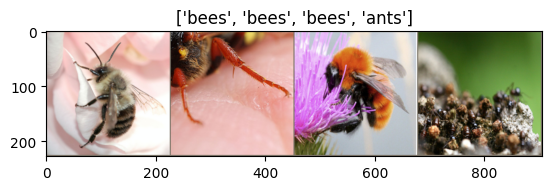

Some Validation Data


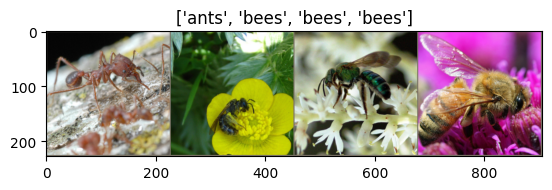

In [6]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))
# Make a grid from batch
print('Some Training Data')
out = torchvision.utils.make_grid(inputs)
imshow(out, title=[class_names[x] for x in classes])

# Get a batch of validation data
inputs, classes = next(iter(dataloaders['val']))
# Make a grid from batch
print('Some Validation Data')
out = torchvision.utils.make_grid(inputs)
imshow(out, title=[class_names[x] for x in classes])

## Training the model

Now, let’s write a general function to train a model. Here, we will illustrate:

+ Scheduling the learning rate
+ Saving the best model

In the following, parameter *scheduler* is an LR scheduler object from *torch.optim.lr_scheduler*.

In [7]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time() # Measure the training time
    
    # initialize the best model, so we can save the best model later
    best_model_wts = copy.deepcopy(model.state_dict()) 
    best_acc = 0.0 

    for epoch in range(num_epochs): # run the number of provided epochs
        print('Epoch {}/{}, Lr {}'.format(epoch, num_epochs - 1, optimizer.param_groups[0]['lr']))
        print('-' * 20)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train': # Depending on the phase...
                model.train()  # ...set model to training mode
            else:
                model.eval()   # ...set model to evaluate mode
            
            running_loss = 0.0
            running_corrects = 0
            
            # Iterate over data.
            
            for inputs, labels in dataloaders[phase]: # load all  and labels ...
                inputs = inputs.to(device) # ...images and 
                labels = labels.to(device) # ...labels to the device e.g. CPU

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

            # deep copy the model if it was better then any model before
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model

## Visualizing the model predictions

Generic function to display predictions for a few images

In [8]:
def visualize_model(model, num_images=16):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//4, num_images//4, images_so_far)
                ax.axis('off')
                ax.set_title('predicted: {}'.format(class_names[preds[j]]))
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

## ConvNet as fixed feature extractor

We want to freeze all the network except the final layer. 
Therefore we set requires_grad == False for all the layers to freeze the parameters so that the gradients are not computed in backward().

You can read more about this in the documentation [here](https://pytorch.org/docs/notes/autograd.html#excluding-subgraphs-from-backward).

In [9]:
# Define the model and set all layers into non-training mode
model_conv = torchvision.models.resnet18(pretrained=True)

# Freeze all layers, no gradient calculation. 
for param in model_conv.parameters():
    param.requires_grad = False

# Re-define the last layer of the resnet18 network
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)

# Copy the model to the device
model_conv = model_conv.to(device)

# Use CrossEntropyLoss
criterion = nn.CrossEntropyLoss()

# Define the optimizer. Observe that only parameters of final layer are being optimized
optimizer = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

# Define the decay rate. Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

c:\Users\Jax\Coding\Neuronale-Netze\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Jax\Coding\Neuronale-Netze\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## Train and evaluate

It should take around 15-25 min on CPU. On GPU though, it takes less than a minute.

In [10]:
model_conv = train_model(model_conv, criterion, optimizer, exp_lr_scheduler, num_epochs=25)

Epoch 0/24, Lr 0.001
--------------------
train Loss: 0.5654 Acc: 0.6926
val Loss: 0.1903 Acc: 0.9412

Epoch 1/24, Lr 0.001
--------------------
train Loss: 0.4662 Acc: 0.7582
val Loss: 0.2490 Acc: 0.9020

Epoch 2/24, Lr 0.001
--------------------
train Loss: 0.4170 Acc: 0.8197
val Loss: 0.1843 Acc: 0.9412

Epoch 3/24, Lr 0.001
--------------------
train Loss: 0.4771 Acc: 0.7992
val Loss: 0.2971 Acc: 0.8824

Epoch 4/24, Lr 0.001
--------------------
train Loss: 0.7682 Acc: 0.7172
val Loss: 0.1790 Acc: 0.9477

Epoch 5/24, Lr 0.001
--------------------
train Loss: 0.4115 Acc: 0.8443
val Loss: 0.2383 Acc: 0.9020

Epoch 6/24, Lr 0.001
--------------------
train Loss: 0.5077 Acc: 0.7869
val Loss: 0.1751 Acc: 0.9608

Epoch 7/24, Lr 0.0001
--------------------
train Loss: 0.3289 Acc: 0.8689
val Loss: 0.1871 Acc: 0.9477

Epoch 8/24, Lr 0.0001
--------------------
train Loss: 0.2551 Acc: 0.8934
val Loss: 0.2059 Acc: 0.9216

Epoch 9/24, Lr 0.0001
--------------------
train Loss: 0.4457 Acc: 0.82

## Visualize the Model

Show a view examples of the predictions

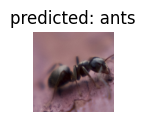

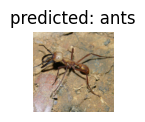

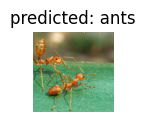

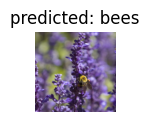

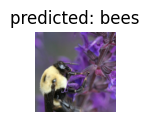

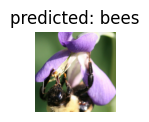

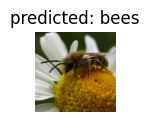

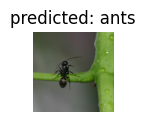

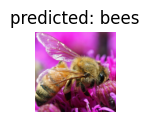

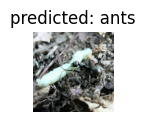

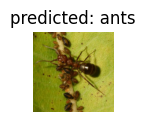

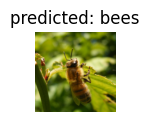

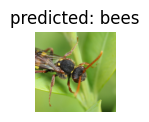

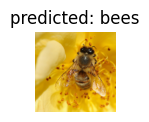

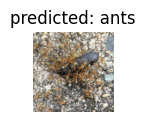

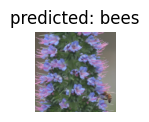

In [11]:
visualize_model(model_conv)
plt.ioff()
plt.show()

-------

## Your own Transfer-Lerning

<span style="color:blue">**It's your turn to implement a transfer learning yourself. You should use the following images, base-model and optimizer:**</span>
+ Images: Cat and Dog Images that should come with the download of the excercise. The data are taken from Kaggle Playground Prediction Competition [Dogs vs. Cats](https://www.kaggle.com/c/dogs-vs-cats)
+ Model: **densenet161** as described in the paper [Densely Connected Convolutional Networks](https://arxiv.org/pdf/1608.06993.pdf)
+ Optimizer: Adam

At the beginning you should start using the resnet18 model as above and change it to the new image data. 
Then it is a good idea to understand the commands:
```python
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)
```
and
```python
optimizer = optim.SGD(model_conv.classifier.parameters(), lr=0.001, momentum=0.9)
```

Then **adapt** those lines to the new model, train the final with **30 epochs** and visualize the result. 

------
Note: The **densenet161** model is part of the torchvision.models. 

In [18]:
data_dir = 'datasets/kagglecatsanddogs_data'

import os.path

# Check if the data_dir is present
if os.path.isdir(data_dir):
    print ("kagglecatsanddogs folder exist.")
else:
    print ("kagglecatsanddogs folder does not exist.")
    raise SystemExit("Stop right there!")

kagglecatsanddogs folder exist.


In [19]:
# Define the data loaders

image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),data_transforms[x]) for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,shuffle=True, num_workers=4) for x in ['train', 'val']}

In [20]:
# Define the model and set all layers into non-training mode
model_conv = torchvision.models.resnet18(pretrained=True)
for param in model_conv.parameters():
    param.requires_grad = False   

# Re-define the last layer of the ResNet network
model_conv.fc = nn.Linear(512, 2)

# Copy the model to the device
model_conv = model_conv.to(device)

# Use CrossEntropyLoss
criterion = nn.CrossEntropyLoss()

# Define the optimizer. Observe that only parameters of final layer are being optimized
optimizer = optim.SGD(model_conv.fc.parameters(), lr=0.01, momentum=0.926)

# Define the decay rate. Decay LR by a factor of 0.1 every 7 epochs
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

In [21]:
model_conv = train_model(model_conv, criterion, optimizer, exp_lr_scheduler, num_epochs=30)

Epoch 0/29, Lr 0.01
--------------------
train Loss: 3.4317 Acc: 1.1639
val Loss: 1.1283 Acc: 0.5686

Epoch 1/29, Lr 0.01
--------------------
train Loss: 3.0795 Acc: 1.3156
val Loss: 0.1507 Acc: 0.6144

Epoch 2/29, Lr 0.01
--------------------
train Loss: 6.1656 Acc: 1.2582
val Loss: 2.1872 Acc: 0.5098

Epoch 3/29, Lr 0.01
--------------------
train Loss: 7.1157 Acc: 1.2377
val Loss: 1.0431 Acc: 0.5882

Epoch 4/29, Lr 0.01
--------------------
train Loss: 7.6909 Acc: 1.3279
val Loss: 0.3503 Acc: 0.6340

Epoch 5/29, Lr 0.01
--------------------
train Loss: 3.8619 Acc: 1.3975
val Loss: 0.2150 Acc: 0.6209

Epoch 6/29, Lr 0.01
--------------------
train Loss: 3.8984 Acc: 1.3975
val Loss: 0.4299 Acc: 0.6144

Epoch 7/29, Lr 0.01
--------------------
train Loss: 4.8619 Acc: 1.2910
val Loss: 0.3364 Acc: 0.6078

Epoch 8/29, Lr 0.01
--------------------
train Loss: 4.0465 Acc: 1.3402
val Loss: 0.3961 Acc: 0.6144

Epoch 9/29, Lr 0.01
--------------------
train Loss: 6.8158 Acc: 1.2172
val Loss: 

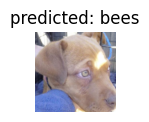

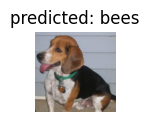

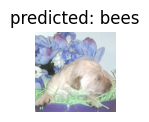

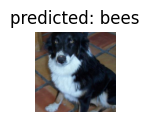

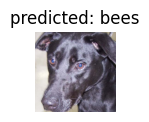

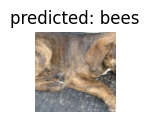

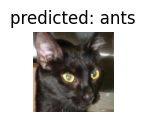

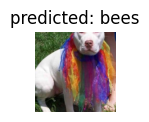

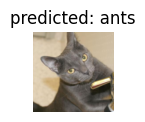

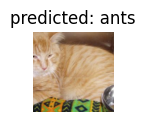

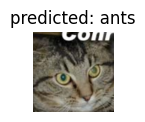

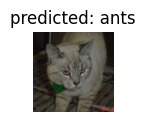

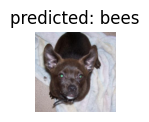

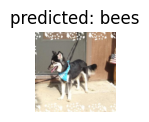

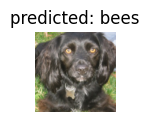

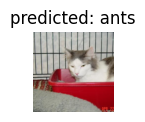

In [22]:
visualize_model(model_conv)
plt.ioff()
plt.show()

<span style="color:blue">**Inline Questions:**</span>
+ Which model resnet18 or densenet161 performs better on the cat and dog images?
 + <span style="color:blue">Your answer:
 + resnet18: Training complete in 31m 46s mit einer val Acc: 1.000000 // bei allen getesteten raten

Densnet161: Training complete in <10m
Best val Acc: 0.980000 // bei allen getestetet Raten

Mit zwar nur einem Prozent Unterschied ist damit resnet18 für ein genaues Ergebnis besser - für ein schnelles Ergebnis, was man im Normalfall nicht benötigt bei so einer Kategorie das Densnet mit nur einem Drittel der Trainingszeit. </span>
+ What is the optimal initial value and decay rate for the learning rate? Are resnet18 or densenet161 and compareable? Describe how you found those parameters?
 + <span style="color:blue">Your answer: 
 + Desto größer das vortrainierte Modell ist, desto besser profitiert es von einer kleinen learning rate für die letzte fc-Layer. 1e-4 für komplexere Modelle und 1e-3 funktionieren ganz gut für Densenet/Resnet, wenn es Schwierigkeiten gegeben hätte, wäre man die lr mit einem Faktor von 1e-1 zum vorherigen Angefangen. 
 Nach dem Beigelegten Paper, sollte die learning rate für gute Ergebnisse nach der 30. Epoche auf 1/10 der anfänglichen lr reduziert werden => lr = 30. Wurzel aus 1/10 == 0.926.

 Die Vergleichbarkeit zwischen den beiden Netzen ist möglich, im Sinne der Anwendung und der Komplexität des Modells.
 Beide werden für die Image-Classification verwendet, wobei das Resnet18 durch eine einfachere Struktur (Addition) sowohl auch nur für "einfache (für und schon noch an sich Komplexe) Bilder" geignet ist, wobei das Densenet161 eine deutlich komplexere (Konkatination) Struktur aufweist, rechenintensiever ist und eine längere Trainingsdauer dadurch hat - Vorteil dadurch ist jedoch, dass Komplexere Bilder dadurch besser verwertet werden können.  </span>

In [23]:
from IPython.display import display, Javascript
display(Javascript('IPython.notebook.save_checkpoint();'))

import helpers

helpers.prepare_submission(additional=[r"datasets/kagglecatsanddogs_data", r"datasets\cifar-10-batches-py"])

<IPython.core.display.Javascript object>

'Abgaben\\82358_Hoegen_Jan_10_20251102_1723.zip'